 *Artificial Intelligence for Vision & NLP* &nbsp; | &nbsp;  *ATU Donegal - Postgrad Diploma in Big Data Analytics & Artificial Intelligence*

# Student Submisison 
Name           : Martin Law                         <br>
Student Number : L00203482                          <br>
Due Date       : Tuesday 12th May 2026              <br>
Assignment     : CA2                                <br>
Module         : AI for Vision and NLP              <br>
Course         : Postgraduate Diploma in Big Data Analytics and AI

## NLP and Vision Pipeline : High Level

This application will analyse scanned or photographed document images using a combined computer vision, OCR, NLP, and reporting pipeline.

The planned high level process is:

1. load scanned or photographed document images
2. preprocess images using OpenCV
3. extract text using Tesseract OCR
4. compare OCR results across different preprocessed image versions
5. clean and process extracted text
6. apply tokenisation, stopword removal, stemming, and lemmatisation
7. extract NLP features such as tokens, stems, lemmas, keywords, and named entities
8. detect visual document features such as text blocks, tables, signatures, diagrams, figures, and form-like regions
9. combine the text and visual findings
10. export structured document summaries, annotated images, CSV files, and JSON reports

At this development stage, notebook now includes image loading, openCV preprocessing, tesseract OCR confidence comparison and OCR text perprocessing

In [1]:
# high-level pipeline placeholder for the first development stage

pipeline_steps = [
    "load scanned or photographed document images",
    "preprocess images using OpenCV",
    "extract text using Tesseract OCR",
    "compare OCR confidence across preprocessing methods",
    "select the best OCR result per doc"
    "clean extracted OCR text",
    "tokenise cleaned text",
    "remove stopwords",
    "apply stemming",
    "apply lemmatisation",
    "extract TF-IDF keywords",
    "extract simple key phrases",
    "extract regex-based named entities and document references",
    "save NLP preprocessing outputs"
]

for step_number, step_description in enumerate(pipeline_steps, start=1):
    print(f"{step_number}. {step_description}")

1. load scanned or photographed document images
2. preprocess images using OpenCV
3. extract text using Tesseract OCR
4. compare OCR confidence across preprocessing methods
5. select the best OCR result per docclean extracted OCR text
6. tokenise cleaned text
7. remove stopwords
8. apply stemming
9. apply lemmatisation
10. extract TF-IDF keywords
11. extract simple key phrases
12. extract regex-based named entities and document references
13. save NLP preprocessing outputs


# Initialisation
Perform pip installs(or use a requirements.txt) <br>
perform imports

## Install packages

In [2]:
# pip installs
# run this cell only if the required packages are not already instlal ed in the selected environment

# %pip install opencv-python pytesseract pandas numpy matplotlib scikit-learn nltk jupyter ipykernel

## Imports

In [3]:
# imports

from pathlib import Path
from collections import Counter
import platform
import json
import shutil
import re

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pytesseract
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer

# Support Functions

In [4]:
# support functions and project folders

PROJECT_DIR = Path.cwd()
INPUT_DIR = PROJECT_DIR / "data" / "input_documents"
OUTPUT_DIR = PROJECT_DIR / "outputs"

PREPROCESSED_DIR = OUTPUT_DIR / "preprocessed_images"
OCR_DIR = OUTPUT_DIR / "ocr_results"
OCR_TEXT_DIR = OUTPUT_DIR / "ocr_text"
NLP_DIR = OUTPUT_DIR / "nlp_results"
CLEANED_TEXT_DIR = OUTPUT_DIR / "cleaned_text"
TEXT_FEATURE_DIR = OUTPUT_DIR / "text_features"
ANNOTATED_DIR = OUTPUT_DIR / "annotated_images"
JSON_DIR = OUTPUT_DIR / "json_reports"
CSV_DIR = OUTPUT_DIR / "csv_reports"

def create_project_folders():
    """ create the folder structure used by this notebook"""
    folders = [
        INPUT_DIR,
        OUTPUT_DIR,
        PREPROCESSED_DIR,
        OCR_DIR,
        OCR_TEXT_DIR,
        NLP_DIR,
        CLEANED_TEXT_DIR,
        TEXT_FEATURE_DIR,
        ANNOTATED_DIR,
        JSON_DIR,
        CSV_DIR
    ]

    for folder in folders:
        folder.mkdir(parents=True, exist_ok=True)

    return folders

def list_input_documents():
    """return supported image files from the input document folder"""
    supported_extensions = [
        "*.jpg",
        "*.jpeg",
        "*.png",
        "*.bmp",
        "*.tif",
        "*.tiff"    
    ]

    image_paths = []

    for extension in supported_extensions:
        image_paths.extend(INPUT_DIR.glob(extension))

    return sorted(image_paths)

created_folders = create_project_folders()
input_documents = list_input_documents()

print("Project directory:", PROJECT_DIR)
print("Operating system:", platform.system())
print("Input directory:", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Preprocessed image directory:", PREPROCESSED_DIR)
print("OCR results directory:", OCR_DIR)
print("NLP results directory:", NLP_DIR)
print("Text feature directory:", TEXT_FEATURE_DIR)
print("Number of input document images found:", len(input_documents))

for image_path in input_documents:
    print("-", image_path.name)

Project directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie
Operating system: Darwin
Input directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/data/input_documents
Output directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs
Preprocessed image directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/preprocessed_images
OCR results directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/ocr_results
NLP results directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/nlp_results
Text feature directory: /Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/text_features
Number of input document images found: 1
- receipt1.png


# NLP

## Stage 5 and Stage 6: OCR Text Preprocessing and NLP Feature Recognition

This section processes the text extracted by Tesseract OCR.

Stage 5 performs the required text preprocessing:

1. clean the raw OCR text
2. convert text to lowercase
3. tokenise the text
4. remove stopwords
5. apply stemming
6. apply lemmatisation
7. save the cleaned text and preprocessing outputs

Stage 6 adds feature recognition:

1. TF-IDF keyword extraction
2. simple key phrase extraction
3. regex-based named entity extraction
4. references to tables, figures, diagrams, and signatures

Higher-level section categorisation and text-image integration are deliberately left for later phases.

In [5]:
# NLP preprocessing functions

# NLTK data is downloaded only if it is missing from the current environment
def ensure_nltk_resource(resource_path, download_name):
    """download an NLTK resource only when it is not already available"""
    try:
        nltk.data.find(resource_path)
    except LookupError:
        nltk.download(download_name, quiet=True)


ensure_nltk_resource("corpora/stopwords", "stopwords")
ensure_nltk_resource("corpora/wordnet", "wordnet")
ensure_nltk_resource("corpora/omw-1.4", "omw-1.4")

STOP_WORDS = set(stopwords.words("english"))
STEMMER = PorterStemmer()
LEMMATIZER = WordNetLemmatizer()


def normalise_text_spacing(text):
    """normalise spacing in OCR text without removing meaningful characters"""
    text = str(text)
    text = text.replace("\r", " ").replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def tokenise_ocr_text(text):
    """tokenise OCR text using a regex that keeps words, numbers, and euro amounts"""
    text = text.lower()

    tokens = re.findall(
        r"€\s*\d+(?:[.,]\d+)?|[a-zA-Z]+(?:'[a-z]+)?|\d+(?:[.,]\d+)?",
        text
    )

    tokens = [token.replace(" ", "") for token in tokens]

    return tokens


def remove_stopwords(tokens):
    """remove common English stopwords and very short alphabetic tokens"""
    filtered_tokens = []

    for token in tokens:
        is_short_word = token.isalpha() and len(token) <= 1

        if token not in STOP_WORDS and not is_short_word:
            filtered_tokens.append(token)

    return filtered_tokens


def stem_tokens(tokens):
    """apply Porter stemming to alphabetic tokens"""
    stemmed_tokens = []

    for token in tokens:
        if token.isalpha():
            stemmed_tokens.append(STEMMER.stem(token))
        else:
            stemmed_tokens.append(token)

    return stemmed_tokens


def lemmatise_tokens(tokens):
    """apply WordNet lemmatisation to alphabetic tokens"""
    lemmatised_tokens = []

    for token in tokens:
        if token.isalpha():
            lemmatised_tokens.append(LEMMATIZER.lemmatize(token))
        else:
            lemmatised_tokens.append(token)

    return lemmatised_tokens


def preprocess_ocr_text(raw_text):
    """run the full Phase 5 preprocessing sequence on OCR text"""
    normalised_text = normalise_text_spacing(raw_text)
    lowercase_text = normalised_text.lower()
    tokens = tokenise_ocr_text(lowercase_text)
    tokens_without_stopwords = remove_stopwords(tokens)
    stems = stem_tokens(tokens_without_stopwords)
    lemmas = lemmatise_tokens(tokens_without_stopwords)
    cleaned_text = " ".join(lemmas)

    return {
        "raw_text": raw_text,
        "normalised_text": normalised_text,
        "lowercase_text": lowercase_text,
        "tokens": tokens,
        "tokens_without_stopwords": tokens_without_stopwords,
        "stems": stems,
        "lemmas": lemmas,
        "cleaned_text": cleaned_text,
        "raw_character_count": len(str(raw_text)),
        "normalised_character_count": len(normalised_text),
        "token_count": len(tokens),
        "tokens_without_stopwords_count": len(tokens_without_stopwords),
        "stem_count": len(stems),
        "lemma_count": len(lemmas)
    }

In [6]:
# NLP development status for this commit

nlp_development_status = {
    "ocr_text_available": "implemented",
    "ocr_text_cleaning": "implemented",
    "tokenisation": "implemented",
    "stopword_removal": "implemented",
    "stemming": "implemented",
    "lemmatisation": "implemented",
    "tfidf_keyword_extraction": "planned for phase",
    "named_entity_extraction": "planned for next phase",
    "figure_table_reference_detection": "planned"
}

nlp_development_status

{'ocr_text_available': 'implemented',
 'ocr_text_cleaning': 'implemented',
 'tokenisation': 'implemented',
 'stopword_removal': 'implemented',
 'stemming': 'implemented',
 'lemmatisation': 'implemented',
 'tfidf_keyword_extraction': 'planned for phase',
 'named_entity_extraction': 'planned for next phase',
 'figure_table_reference_detection': 'planned'}

# Vision

## Stage 3: Image Preprocessing and Enhancement

This section prepares scanned or photographed document images for later OCR and feature detection.

The preprocessing steps are:

1. load the document image
2. convert it to grayscale
3. reduce noise using median blur
4. enhance contrast using CLAHE
5. apply Otsu thresholding
6. apply adaptive thresholding
7. apply a cleaner adaptive threshold for OCR comparison
8. detect edges using Canny edge detection
9. save the processed images for later stages

The OCR phase below will compare several of these preprocessed outputs and select the one with the best tereract confidence score

In [7]:
# load and display input document images

input_documents = list_input_documents()

if len(input_documents) == 0:
    raise FileNotFoundError(
        f"No document images were found in {INPUT_DIR}. "
        "Add .jpg, .jpeg, .png, .bmp, .tif, or .tiff files before running this cell"
    )

loaded_documents = []

for image_path in input_documents:
    image = cv2.imread(str(image_path))

    if image is None:
        print(f"Could not load image: {image_path.name}")
        continue

    loaded_documents.append({
        "path": image_path,
        "filename": image_path.name,
        "image": image,
        "height": image.shape[0],
        "width": image.shape[1],
        "channels": image.shape[2] if len(image.shape) == 3 else 1
    })

print("Loaded document images:")

for document in loaded_documents:
    print(
        f"- {document['filename']} "
        f"({document['width']} x {document['height']}, "
        f"{document['channels']} channel(s))"
    )

Loaded document images:
- receipt1.png (1288 x 2248, 3 channel(s))


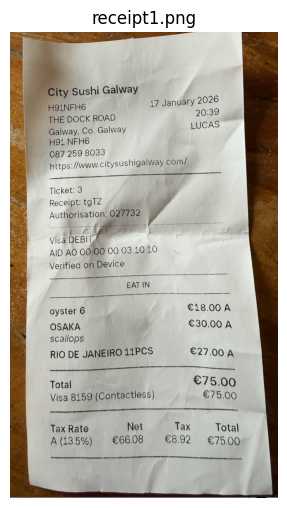

In [8]:
# display a sample of the loaded document images

documents_to_display = loaded_documents[:4]

plt.figure(figsize=(14, 10))

for index, document in enumerate(documents_to_display, start=1):
    image_rgb = cv2.cvtColor(document["image"], cv2.COLOR_BGR2RGB)

    plt.subplot(2, 2, index)
    plt.imshow(image_rgb)
    plt.axis("off")
    plt.title(document["filename"])

plt.tight_layout()
plt.show()

In [9]:
# OpenCV preprocessing functions

def preprocess_document_image(image):
    """Apply basic OpenCV preprocessing steps to a document image."""
    if image is None:
        raise ValueError("Cannot preprocess an empty image.")

    # convert from colour to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # reduce small noise while keeping text edges reasonably sharp
    denoised = cv2.medianBlur(gray, 3)

    # improve local contrast, useful for photographed documents with uneven lighting
    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )
    enhanced = clahe.apply(denoised)

    # global thresholding using Otsu's method
    _, otsu_threshold = cv2.threshold(
        enhanced,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # adaptive thresholding handles uneven lighting better than a single global threshold
    adaptive_threshold = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        31,
        15
    )

    # a softer adaptive threshold version for OCR comparison
    adaptive_threshold_clean = cv2.adaptiveThreshold(
        enhanced,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        51,
        11
    )

    # remove small isolated black noise from the thresholded image
    noise_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))

    adaptive_threshold_clean = cv2.morphologyEx(
        adaptive_threshold_clean,
        cv2.MORPH_OPEN,
        noise_kernel
    )

    # edge detection is useful later for detecting boxes, tables, and page boundaries
    edges = cv2.Canny(
        enhanced,
        threshold1=50,
        threshold2=150
    )

    return {
        "gray": gray,
        "denoised": denoised,
        "enhanced": enhanced,
        "otsu_threshold": otsu_threshold,
        "adaptive_threshold": adaptive_threshold,
        "adaptive_threshold_clean": adaptive_threshold_clean,
        "edges": edges
    }


In [10]:
# preprocess all loaded document images and save the results

if "loaded_documents" not in globals():
    raise NameError("loaded_documents does not exist. Run the image loading cell before this cell.")

if len(loaded_documents) == 0:
    raise ValueError("No loaded documents are available for preprocessing.")

preprocessed_documents = []

for document in loaded_documents:
    filename_stem = Path(document["filename"]).stem

    processed_images = preprocess_document_image(document["image"])

    output_paths = {}

    for processing_name, processed_image in processed_images.items():
        output_path = PREPROCESSED_DIR / f"{filename_stem}_{processing_name}.png"
        cv2.imwrite(str(output_path), processed_image)
        output_paths[processing_name] = output_path

    preprocessed_documents.append({
        "filename": document["filename"],
        "original_image": document["image"],
        "processed_images": processed_images,
        "output_paths": output_paths
    })

print("Preprocessed document images saved:")

for document in preprocessed_documents:
    print(f"- {document['filename']}")

    for processing_name, output_path in document["output_paths"].items():
        print(f"  {processing_name}: {output_path.name}")


Preprocessed document images saved:
- receipt1.png
  gray: receipt1_gray.png
  denoised: receipt1_denoised.png
  enhanced: receipt1_enhanced.png
  otsu_threshold: receipt1_otsu_threshold.png
  adaptive_threshold: receipt1_adaptive_threshold.png
  adaptive_threshold_clean: receipt1_adaptive_threshold_clean.png
  edges: receipt1_edges.png


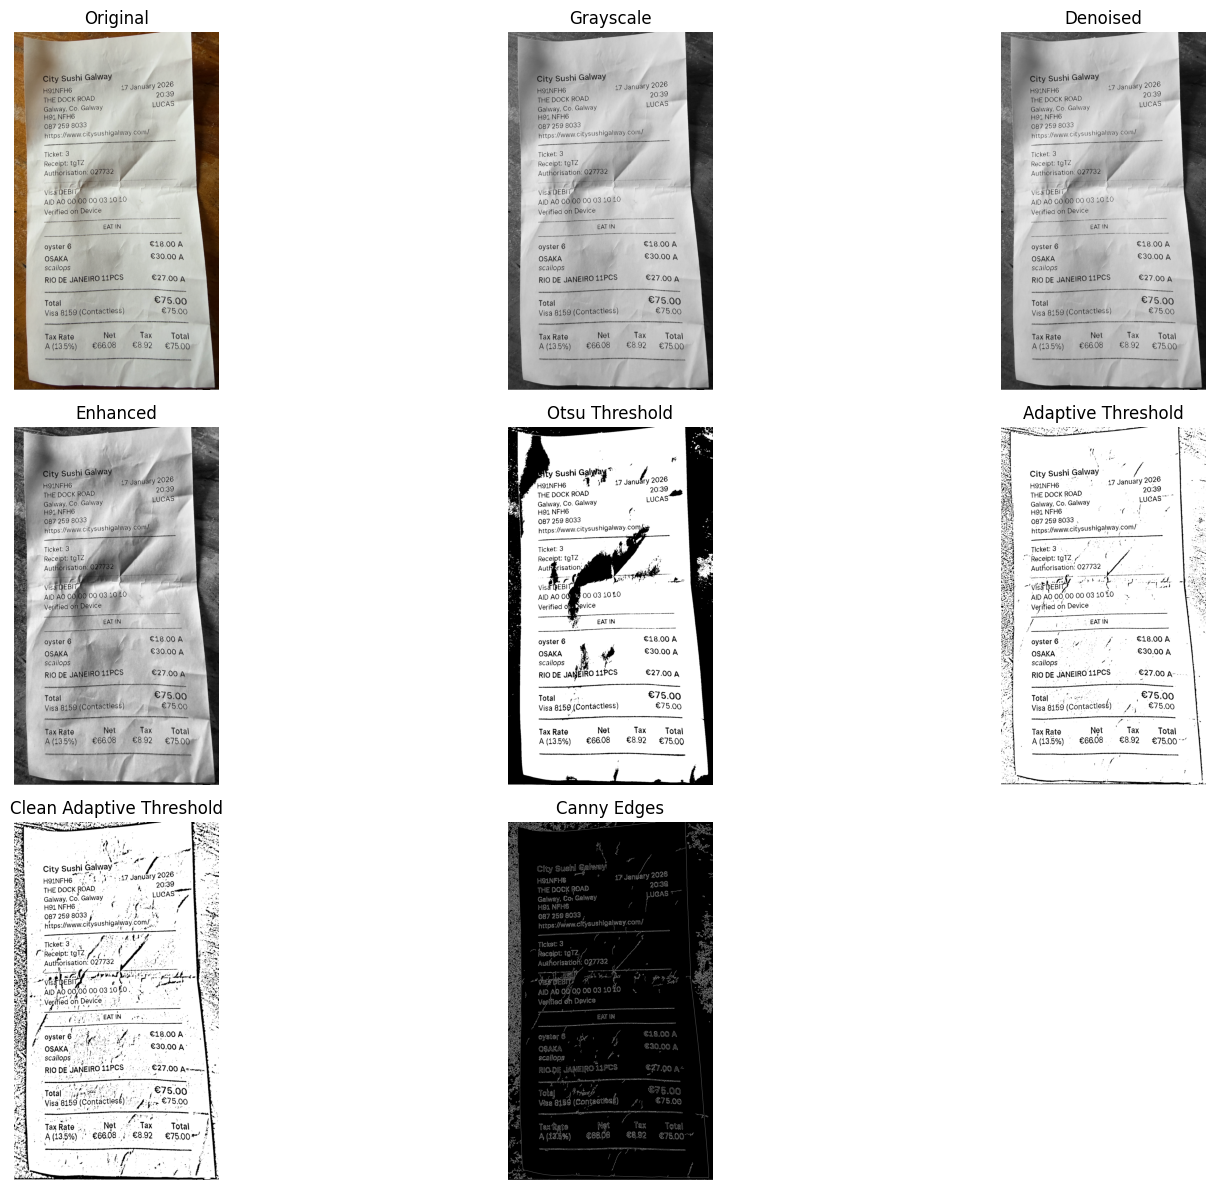

Displayed preprocessing results for: receipt1.png


In [11]:
# display preprocessing results for the first document

example_document = preprocessed_documents[0]

original_rgb = cv2.cvtColor(example_document["original_image"], cv2.COLOR_BGR2RGB)

display_images = [
    ("Original", original_rgb, None),
    ("Grayscale", example_document["processed_images"]["gray"], "gray"),
    ("Denoised", example_document["processed_images"]["denoised"], "gray"),
    ("Enhanced", example_document["processed_images"]["enhanced"], "gray"),
    ("Otsu Threshold", example_document["processed_images"]["otsu_threshold"], "gray"),
    ("Adaptive Threshold", example_document["processed_images"]["adaptive_threshold"], "gray"),
    ("Clean Adaptive Threshold", example_document["processed_images"]["adaptive_threshold_clean"], "gray"),
    ("Canny Edges", example_document["processed_images"]["edges"], "gray")
]

plt.figure(figsize=(16, 12))

for index, (title, image, colour_map) in enumerate(display_images, start=1):
    plt.subplot(3, 3, index)
    plt.imshow(image, cmap=colour_map)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

print("Displayed preprocessing results for:", example_document["filename"])


## Stage 4: Tesseract OCR Extraction and Confidence Comparison

This stage extracts text from each document image using Tesseract OCR.

To avoid assuming that one preprocessing method is always best, OCR is tested on several image versions:

1. grayscale
2. denoised
3. contrast-enhanced
4. clean adaptive threshold

The notebook then compares the average Tesseract confidence score and selects the best OCR result for each document.

This stage addresses the OCR accuracy part of the rubric. NLP preprocessing is added in the next phase.

In [12]:
# Tesseract OCR configuration

OCR_CONFIG = "--oem 3 --psm 6"

def configure_tesseract_for_current_system():
    """configure the Tesseract executable path where needed"""
    system_name = platform.system()

    if system_name == "Darwin":
        possible_paths = [
            "/opt/homebrew/bin/tesseract",
            "/usr/local/bin/tesseract"
        ]

        for possible_path in possible_paths:
            if Path(possible_path).exists():
                pytesseract.pytesseract.tesseract_cmd = possible_path
                break

    detected_path = shutil.which("tesseract") or pytesseract.pytesseract.tesseract_cmd

    try:
        version = pytesseract.get_tesseract_version()
        print("Tesseract detected:", version)
        print("Tesseract path:", detected_path)
    except Exception as error:
        raise RuntimeError(
            "Tesseract could not be found by pytesseract. "
            "On macOS, install it with: brew install tesseract"
        ) from error


configure_tesseract_for_current_system()

Tesseract detected: 5.5.2
Tesseract path: /opt/homebrew/bin/tesseract


In [13]:
# OCR helper functions

def normalise_ocr_dataframe(ocr_dataframe):
    """clean the dataframe returned by pytesseract.image_to_data"""
    cleaned_dataframe = ocr_dataframe.copy()

    cleaned_dataframe["text"] = cleaned_dataframe["text"].fillna("").astype(str)
    cleaned_dataframe["text"] = cleaned_dataframe["text"].str.strip()
    cleaned_dataframe["conf"] = pd.to_numeric(cleaned_dataframe["conf"], errors="coerce")

    cleaned_dataframe = cleaned_dataframe[
        (cleaned_dataframe["text"] != "") &
        (cleaned_dataframe["conf"].notna()) &
        (cleaned_dataframe["conf"] >= 0)
    ].copy()

    return cleaned_dataframe


def run_ocr_on_image(image):
    """run Tesseract OCR on one image and return text, word data, and confidence metrics"""
    ocr_dataframe = pytesseract.image_to_data(
        image,
        config=OCR_CONFIG,
        output_type=pytesseract.Output.DATAFRAME
    )

    ocr_dataframe = normalise_ocr_dataframe(ocr_dataframe)

    extracted_text = " ".join(ocr_dataframe["text"].tolist())

    if len(ocr_dataframe) == 0:
        average_confidence = 0.0
        median_confidence = 0.0
    else:
        average_confidence = float(ocr_dataframe["conf"].mean())
        median_confidence = float(ocr_dataframe["conf"].median())

    return {
        "text": extracted_text,
        "ocr_dataframe": ocr_dataframe,
        "average_confidence": average_confidence,
        "median_confidence": median_confidence,
        "word_count": int(len(ocr_dataframe)),
        "character_count": int(len(extracted_text))
    }


def select_ocr_candidate_images(preprocessed_document):
    """select the preprocessed image versions used for OCR comparison"""
    processed_images = preprocessed_document["processed_images"]

    candidate_names = [
        "gray",
        "denoised",
        "enhanced",
        "adaptive_threshold_clean"
    ]

    candidates = {}

    for candidate_name in candidate_names:
        if candidate_name in processed_images:
            candidates[candidate_name] = processed_images[candidate_name]

    return candidates

In [14]:
# run OCR on each selected preprocessing version and select the best result

if "preprocessed_documents" not in globals():
    raise NameError("preprocessed_documents does not exist. Run the preprocessing cells before this OCR cell.")

ocr_results = []

for document in preprocessed_documents:
    filename = document["filename"]
    filename_stem = Path(filename).stem

    candidate_images = select_ocr_candidate_images(document)
    candidate_results = []

    for candidate_name, candidate_image in candidate_images.items():
        result = run_ocr_on_image(candidate_image)

        ocr_csv_path = OCR_DIR / f"{filename_stem}_{candidate_name}_ocr_words.csv"
        result["ocr_dataframe"].to_csv(ocr_csv_path, index=False)

        candidate_results.append({
            "candidate_name": candidate_name,
            "text": result["text"],
            "average_confidence": result["average_confidence"],
            "median_confidence": result["median_confidence"],
            "word_count": result["word_count"],
            "character_count": result["character_count"],
            "ocr_csv_path": str(ocr_csv_path)
        })

    best_candidate = max(
        candidate_results,
        key=lambda item: (
            item["average_confidence"],
            item["word_count"],
            item["character_count"]
        )
    )

    best_text_path = OCR_TEXT_DIR / f"{filename_stem}_best_ocr_text.txt"

    with open(best_text_path, "w", encoding="utf-8") as text_file:
        text_file.write(best_candidate["text"])

    ocr_results.append({
        "filename": filename,
        "candidate_results": candidate_results,
        "best_candidate_name": best_candidate["candidate_name"],
        "best_average_confidence": best_candidate["average_confidence"],
        "best_median_confidence": best_candidate["median_confidence"],
        "best_word_count": best_candidate["word_count"],
        "best_character_count": best_candidate["character_count"],
        "best_text": best_candidate["text"],
        "best_text_path": str(best_text_path)
    })

print("OCR completed for document images:")

for result in ocr_results:
    print(
        f"- {result['filename']}: "
        f"best={result['best_candidate_name']}, "
        f"avg_conf={result['best_average_confidence']:.2f}, "
        f"words={result['best_word_count']}"
    )


OCR completed for document images:
- receipt1.png: best=denoised, avg_conf=68.68, words=92


In [15]:
# display OCR confidence comparison

ocr_summary_rows = []

for result in ocr_results:
    for candidate in result["candidate_results"]:
        ocr_summary_rows.append({
            "document": result["filename"],
            "ocr_source": candidate["candidate_name"],
            "average_confidence": round(candidate["average_confidence"], 2),
            "median_confidence": round(candidate["median_confidence"], 2),
            "word_count": candidate["word_count"],
            "character_count": candidate["character_count"],
            "selected_as_best": candidate["candidate_name"] == result["best_candidate_name"]
        })

ocr_summary_df = pd.DataFrame(ocr_summary_rows)

ocr_summary_csv_path = CSV_DIR / "ocr_confidence_summary.csv"
ocr_summary_df.to_csv(ocr_summary_csv_path, index=False)

ocr_summary_df


,document,ocr_source,average_confidence,median_confidence,word_count,character_count,selected_as_best
0,receipt1.png,gray,63.03,82.26,90,470,False
1,receipt1.png,denoised,68.68,88.00,92,477,True
2,receipt1.png,enhanced,52.18,44.81,116,575,False
3,receipt1.png,adaptive_threshold_clean,27.24,25.97,122,504,False


In [16]:
# display best OCR text for the first document

example_ocr_result = ocr_results[0]

print("Document:", example_ocr_result["filename"])
print("Best OCR source:", example_ocr_result["best_candidate_name"])
print("Average confidence:", round(example_ocr_result["best_average_confidence"], 2))
print("Median confidence:", round(example_ocr_result["best_median_confidence"], 2))
print("Word count:", example_ocr_result["best_word_count"])
print()
print("Best OCR text preview:")
print("-" * 80)
print(example_ocr_result["best_text"][:2000])


Document: receipt1.png
Best OCR source: denoised
Average confidence: 68.68
Median confidence: 88.0
Word count: 92

Best OCR text preview:
--------------------------------------------------------------------------------
faleecity Sushi Galway Tie H9ANFH6 47 January 2026 fee THE DOCK ROAD 20:39 y) Galway, Co. Galway LUCAS te dp H91t NFH6 wan 087 259 8033 - & https://www.citysushigalway.com/ J : i Ticket: 3 i. Pe Receipt: tg1Z i ~ Authorisation: 027732 A oa : AID AO 00/00 00 03 10 10 Re, Verified on Device iy EAT IN eo & oyster 6 €18.00A OSAKA €30.00 A scallops RIO DE JANEIRO 11PCS €27.00 A . Total €75.00 Visa 8459 (Contactless) €75.00 ee Tax Rate Net Tax Total A (13.5%) €66,08 €8.92 €75.00


## Stage 5: Apply NLP Preprocessing to OCR Text

This stage applies the NLP preprocessing functions to the best OCR result selected for each document.

The output separates the raw OCR text from the cleaned and processed text so that the effect of tokenisation, stopword removal, stemming, and lemmatisation can be inspected clearly.


In [17]:
# apply NLP preprocessing to the best OCR result for each document

if "ocr_results" not in globals():
    raise NameError("ocr_results does not exist. Run the OCR cells before this NLP preprocessing cell.")

if len(ocr_results) == 0:
    raise ValueError("No OCR results are available for NLP preprocessing.")

nlp_results = []

for ocr_result in ocr_results:
    filename = ocr_result["filename"]
    filename_stem = Path(filename).stem
    raw_text = ocr_result["best_text"]

    processed_text = preprocess_ocr_text(raw_text)

    nlp_json_path = NLP_DIR / f"{filename_stem}_nlp_preprocessing.json"
    cleaned_text_path = CLEANED_TEXT_DIR / f"{filename_stem}_cleaned_text.txt"

    nlp_record = {
        "filename": filename,
        "best_ocr_source": ocr_result["best_candidate_name"],
        "best_ocr_average_confidence": ocr_result["best_average_confidence"],
        "best_ocr_median_confidence": ocr_result["best_median_confidence"],
        "preprocessing": processed_text,
        "output_paths": {
            "nlp_json": str(nlp_json_path),
            "cleaned_text": str(cleaned_text_path)
        }
    }

    with open(nlp_json_path, "w", encoding="utf-8") as json_file:
        json.dump(nlp_record, json_file, indent=4, ensure_ascii=False)

    with open(cleaned_text_path, "w", encoding="utf-8") as text_file:
        text_file.write(processed_text["cleaned_text"])

    nlp_results.append(nlp_record)

print("NLP preprocessing completed:")

for result in nlp_results:
    print(f"- {result['filename']}")
    print(f"  cleaned text: {Path(result['output_paths']['cleaned_text']).name}")
    print(f"  NLP JSON: {Path(result['output_paths']['nlp_json']).name}")

NLP preprocessing completed:
- receipt1.png
  cleaned text: receipt1_cleaned_text.txt
  NLP JSON: receipt1_nlp_preprocessing.json


In [18]:
# create and display a summary of the NLP preprocessing results

nlp_summary_rows = []

for result in nlp_results:
    preprocessing = result["preprocessing"]

    nlp_summary_rows.append({
        "document": result["filename"],
        "best_ocr_source": result["best_ocr_source"],
        "best_ocr_average_confidence": round(result["best_ocr_average_confidence"], 2),
        "raw_character_count": preprocessing["raw_character_count"],
        "normalised_character_count": preprocessing["normalised_character_count"],
        "token_count": preprocessing["token_count"],
        "tokens_without_stopwords_count": preprocessing["tokens_without_stopwords_count"],
        "stem_count": preprocessing["stem_count"],
        "lemma_count": preprocessing["lemma_count"],
        "cleaned_text_preview": preprocessing["cleaned_text"][:150]
    })

nlp_summary_df = pd.DataFrame(nlp_summary_rows)

nlp_summary_csv_path = CSV_DIR / "text_preprocessing_summary.csv"
nlp_summary_df.to_csv(nlp_summary_csv_path, index=False)

nlp_summary_df

,document,best_ocr_source,best_ocr_average_confidence,raw_character_count,normalised_character_count,token_count,tokens_without_stopwords_count,stem_count,lemma_count,cleaned_text_preview
0,receipt1.png,denoised,68.68,477,477,100,82,82,82,faleecity sushi galway tie 9 anfh 6 47 january...


In [19]:
# inspect the NLP preprocessing output for the first document

example_nlp_result = nlp_results[0]
example_preprocessing = example_nlp_result["preprocessing"]

print("Document:", example_nlp_result["filename"])
print("Best OCR source:", example_nlp_result["best_ocr_source"])
print()

print("Raw OCR text preview:")
print("-" * 80)
print(example_preprocessing["normalised_text"][:1000])
print()

print("Tokens:")
print(example_preprocessing["tokens"][:80])
print()

print("Tokens after stopword removal:")
print(example_preprocessing["tokens_without_stopwords"][:80])
print()

print("Stems:")
print(example_preprocessing["stems"][:80])
print()

print("Lemmas:")
print(example_preprocessing["lemmas"][:80])
print()

print("Cleaned text preview:")
print("-" * 80)
print(example_preprocessing["cleaned_text"][:1000])


Document: receipt1.png
Best OCR source: denoised

Raw OCR text preview:
--------------------------------------------------------------------------------
faleecity Sushi Galway Tie H9ANFH6 47 January 2026 fee THE DOCK ROAD 20:39 y) Galway, Co. Galway LUCAS te dp H91t NFH6 wan 087 259 8033 - & https://www.citysushigalway.com/ J : i Ticket: 3 i. Pe Receipt: tg1Z i ~ Authorisation: 027732 A oa : AID AO 00/00 00 03 10 10 Re, Verified on Device iy EAT IN eo & oyster 6 €18.00A OSAKA €30.00 A scallops RIO DE JANEIRO 11PCS €27.00 A . Total €75.00 Visa 8459 (Contactless) €75.00 ee Tax Rate Net Tax Total A (13.5%) €66,08 €8.92 €75.00

Tokens:
['faleecity', 'sushi', 'galway', 'tie', 'h', '9', 'anfh', '6', '47', 'january', '2026', 'fee', 'the', 'dock', 'road', '20', '39', 'y', 'galway', 'co', 'galway', 'lucas', 'te', 'dp', 'h', '91', 't', 'nfh', '6', 'wan', '087', '259', '8033', 'https', 'www', 'citysushigalway', 'com', 'j', 'i', 'ticket', '3', 'i', 'pe', 'receipt', 'tg', '1', 'z', 'i', 'authorisat

## Stage 6: NLP Feature Recognition

This stage extracts meaningful textual features from the cleaned OCR text.

The features extracted in this phase are:

1. TF-IDF keywords
2. simple key phrases from cleaned tokens
3. regex-based named entities and document patterns
4. references to tables, figures, diagrams, and signatures

This phase directly supports the feature-recognition part of the rubric. Section categorisation and image-region linking are left for the next phases.

In [20]:
# Phase 6 NLP feature recognition functions

def deduplicate_preserve_order(values):
    """remove duplicates while preserving the original order"""
    seen = set()
    deduplicated_values = []

    for value in values:
        normalised_value = str(value).strip()

        if normalised_value == "":
            continue

        key = normalised_value.lower()

        if key not in seen:
            seen.add(key)
            deduplicated_values.append(normalised_value)

    return deduplicated_values


def extract_regex_entities(text):
    """extract simple document entities and patterns using regular expressions"""
    text = str(text)

    month_names = (
        "January|February|March|April|May|June|July|August|"
        "September|October|November|December"
    )

    date_patterns = [
        rf"\b\d{{1,2}}\s+(?:{month_names})\s+\d{{4}}\b",
        r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b",
        r"\b\d{4}[/-]\d{1,2}[/-]\d{1,2}\b"
    ]

    dates = []

    for pattern in date_patterns:
        dates.extend(re.findall(pattern, text, flags=re.IGNORECASE))

    money_values = re.findall(
        r"[€£$]\s*\d+(?:[.,]\d{2})?",
        text
    )

    times = re.findall(
        r"\b\d{1,2}:\d{2}\b",
        text
    )

    urls = re.findall(
        r"\b(?:https?://|www\.)[^\s]+",
        text,
        flags=re.IGNORECASE
    )

    phone_numbers = re.findall(
        r"\b(?:\+?\d[\d\s-]{6,}\d)\b",
        text
    )

    percentages = re.findall(
        r"\b\d+(?:[.,]\d+)?\s*%",
        text
    )

    document_references = re.findall(
        r"\b(?:invoice|receipt|ticket|form|report|notice|ref|reference|id|authorisation|authorization|aid)\s*[:#-]?\s*[A-Z0-9][A-Z0-9_-]*\b",
        text,
        flags=re.IGNORECASE
    )

    return {
        "dates": deduplicate_preserve_order(dates),
        "money_values": deduplicate_preserve_order(money_values),
        "times": deduplicate_preserve_order(times),
        "urls": deduplicate_preserve_order(urls),
        "phone_numbers": deduplicate_preserve_order(phone_numbers),
        "percentages": deduplicate_preserve_order(percentages),
        "document_references": deduplicate_preserve_order(document_references)
    }


def extract_document_reference_terms(text, context_window=45):
    """find references to visual or structural document elements"""
    text = str(text)
    reference_terms = [
        "table",
        "figure",
        "diagram",
        "image",
        "signature",
        "caption",
        "chart"
    ]

    matches = []

    for term in reference_terms:
        for match in re.finditer(rf"\b{term}s?\b", text, flags=re.IGNORECASE):
            start = max(match.start() - context_window, 0)
            end = min(match.end() + context_window, len(text))

            matches.append({
                "term": match.group(0),
                "snippet": text[start:end].strip()
            })

    return matches


def extract_key_phrases_from_tokens(tokens, max_phrases=12):
    """extract simple key phrases using bigrams and trigrams from cleaned tokens"""
    useful_tokens = [
        str(token).lower()
        for token in tokens
        if len(str(token)) > 2 and not str(token).startswith("€")
    ]

    phrase_counter = Counter()

    for ngram_size in [2, 3]:
        for index in range(0, max(len(useful_tokens) - ngram_size + 1, 0)):
            phrase_tokens = useful_tokens[index:index + ngram_size]

            if all(token.replace(".", "").replace(",", "").isdigit() for token in phrase_tokens):
                continue

            phrase = " ".join(phrase_tokens)
            phrase_counter[phrase] += 1

    top_phrases = []

    for phrase, count in phrase_counter.most_common(max_phrases):
        top_phrases.append({
            "phrase": phrase,
            "count": int(count)
        })

    return top_phrases


def build_tfidf_keyword_results(nlp_results, top_n=12):
    """calculate TF-IDF keywords across the available document set"""
    cleaned_texts = [
        result["preprocessing"]["cleaned_text"]
        for result in nlp_results
    ]

    # TF-IDF requires non-empty text, so use a placeholder only for empty OCR failures
    vectorizer_input = [
        text if str(text).strip() else "empty_document_text"
        for text in cleaned_texts
    ]

    vectorizer = TfidfVectorizer(
        max_features=100,
        ngram_range=(1, 2),
        token_pattern=r"(?u)\b\w[\w.-]+\b"
    )

    tfidf_matrix = vectorizer.fit_transform(vectorizer_input)
    feature_names = vectorizer.get_feature_names_out()

    keyword_results = {}

    for row_index, result in enumerate(nlp_results):
        row = tfidf_matrix[row_index].toarray()[0]
        ranked_indexes = row.argsort()[::-1]

        keywords = []

        for feature_index in ranked_indexes[:top_n]:
            score = row[feature_index]

            if score <= 0:
                continue

            keywords.append({
                "keyword": feature_names[feature_index],
                "score": float(score)
            })

        keyword_results[result["filename"]] = keywords

    return keyword_results

In [21]:
# apply Phase 6 feature recognition to the NLP results

if "nlp_results" not in globals():
    raise NameError("nlp_results does not exist. Run the Phase 5 NLP preprocessing cells before this cell.")

if len(nlp_results) == 0:
    raise ValueError("No NLP results are available for feature recognition.")

tfidf_keyword_lookup = build_tfidf_keyword_results(nlp_results)

text_feature_results = []

for result in nlp_results:
    filename = result["filename"]
    filename_stem = Path(filename).stem
    preprocessing = result["preprocessing"]

    normalised_text = preprocessing["normalised_text"]
    cleaned_tokens = preprocessing["tokens_without_stopwords"]

    regex_entities = extract_regex_entities(normalised_text)
    visual_reference_terms = extract_document_reference_terms(normalised_text)
    key_phrases = extract_key_phrases_from_tokens(cleaned_tokens)

    text_feature_record = {
        "filename": filename,
        "best_ocr_source": result["best_ocr_source"],
        "best_ocr_average_confidence": result["best_ocr_average_confidence"],
        "tfidf_keywords": tfidf_keyword_lookup.get(filename, []),
        "key_phrases": key_phrases,
        "regex_entities": regex_entities,
        "visual_reference_terms": visual_reference_terms
    }

    feature_json_path = TEXT_FEATURE_DIR / f"{filename_stem}_text_features.json"

    with open(feature_json_path, "w", encoding="utf-8") as json_file:
        json.dump(text_feature_record, json_file, indent=4, ensure_ascii=False)

    text_feature_record["output_paths"] = {
        "text_features_json": str(feature_json_path)
    }

    text_feature_results.append(text_feature_record)

print("Text feature recognition completed:")

for result in text_feature_results:
    print(f"- {result['filename']}")
    print(f"  features JSON: {Path(result['output_paths']['text_features_json']).name}")
    print(f"  TF-IDF keywords: {', '.join([item['keyword'] for item in result['tfidf_keywords'][:5]])}")

Text feature recognition completed:
- receipt1.png
  features JSON: receipt1_text_features.json
  TF-IDF keywords: 00, 75.00, galway, 00 00, tax


In [22]:
# create and display a summary of the text feature recognition results

feature_summary_rows = []

for result in text_feature_results:
    entities = result["regex_entities"]

    feature_summary_rows.append({
        "document": result["filename"],
        "best_ocr_source": result["best_ocr_source"],
        "best_ocr_average_confidence": round(result["best_ocr_average_confidence"], 2),
        "top_tfidf_keywords": ", ".join([item["keyword"] for item in result["tfidf_keywords"][:8]]),
        "top_key_phrases": ", ".join([item["phrase"] for item in result["key_phrases"][:5]]),
        "dates": ", ".join(entities["dates"]),
        "money_values": ", ".join(entities["money_values"]),
        "times": ", ".join(entities["times"]),
        "urls": ", ".join(entities["urls"]),
        "phone_numbers": ", ".join(entities["phone_numbers"]),
        "percentages": ", ".join(entities["percentages"]),
        "document_references": ", ".join(entities["document_references"]),
        "visual_reference_terms_found": len(result["visual_reference_terms"])
    })

text_feature_summary_df = pd.DataFrame(feature_summary_rows)

text_feature_summary_csv_path = CSV_DIR / "text_feature_summary.csv"
text_feature_summary_df.to_csv(text_feature_summary_csv_path, index=False)

text_feature_summary_df


,document,best_ocr_source,best_ocr_average_confidence,top_tfidf_keywords,top_key_phrases,dates,money_values,times,urls,phone_numbers,percentages,document_references,visual_reference_terms_found
0,receipt1.png,denoised,68.68,"00, 75.00, galway, 00 00, tax, total, 10, fale...","faleecity sushi, sushi galway, galway tie, tie...",47 January 2026,"€18.00, €30.00, €27.00, €75.00, €66,08, €8.92",20:39,https://www.citysushigalway.com/,"087 259 8033, 00 00 03 10 10",13.5%,"Ticket: 3, Receipt: tg1Z, Authorisation: 02773...",0


In [23]:
# inspect Phase 6 feature recognition output for the first document

example_feature_result = text_feature_results[0]

print("Document:", example_feature_result["filename"])
print("Best OCR source:", example_feature_result["best_ocr_source"])
print()

print("Top TF-IDF keywords:")
print(json.dumps(example_feature_result["tfidf_keywords"][:10], indent=4, ensure_ascii=False))
print()

print("Key phrases:")
print(json.dumps(example_feature_result["key_phrases"][:10], indent=4, ensure_ascii=False))
print()

print("Regex-based entities:")
print(json.dumps(example_feature_result["regex_entities"], indent=4, ensure_ascii=False))
print()

print("References to visual/structural document elements:")
print(json.dumps(example_feature_result["visual_reference_terms"], indent=4, ensure_ascii=False))

Document: receipt1.png
Best OCR source: denoised

Top TF-IDF keywords:
[
    {
        "keyword": "00",
        "score": 0.25724787771376323
    },
    {
        "keyword": "75.00",
        "score": 0.25724787771376323
    },
    {
        "keyword": "galway",
        "score": 0.25724787771376323
    },
    {
        "keyword": "00 00",
        "score": 0.17149858514250882
    },
    {
        "keyword": "tax",
        "score": 0.17149858514250882
    },
    {
        "keyword": "total",
        "score": 0.17149858514250882
    },
    {
        "keyword": "10",
        "score": 0.17149858514250882
    },
    {
        "keyword": "faleecity",
        "score": 0.08574929257125441
    },
    {
        "keyword": "47 january",
        "score": 0.08574929257125441
    },
    {
        "keyword": "66",
        "score": 0.08574929257125441
    }
]

Key phrases:
[
    {
        "phrase": "faleecity sushi",
        "count": 1
    },
    {
        "phrase": "sushi galway",
        "count": 1
   

# Multi-modal

## Stage 6 Multi-modal Plan

This section will later combine OCR, NLP, text-feature, and computer vision outputs into one document-level result.

The notebook now provides:

1. best OCR text per document
2. OCR confidence by preprocessing method
3. OCR word-level CSV outputs
4. selected OCR source for each document
5. cleaned OCR text
6. tokens
7. tokens after stopword removal
8. stems
9. lemmas
10. TF-IDF keywords
11. simple key phrases
12. regex-based entities
13. references to tables, figures, diagrams, images, captions, charts, and signatures

The next phases will add section categorisation, visual feature detection, segmentation, and text-image integration.

In [24]:
# multi-modal development status for this commit

multimodal_development_status = {
    "ocr_text_extraction": "implemented",
    "ocr_confidence_comparison": "implemented",
    "ocr_word_csv_export": "implemented",
    "text_cleaning": "implemented",
    "tokenisation": "implemented",
    "stopword_removal": "implemented",
    "stemming": "implemented",
    "lemmatisation": "implemented",
    "tfidf_keyword_extraction": "implemented",
    "key_phrase_extraction": "implemented",
    "named_entity_extraction": "implemented",
    "document_reference_detection": "implemented",
    "ocr_to_layout_mapping": "planned",
    "section_categorisation": "planned",
    "visual_feature_detection": "planned",
    "segmentation": "planned",
    "json_report_generation": "planned",
    "csv_summary_generation": "planned",
    "annotated_image_generation": "planned"
}

multimodal_development_status

{'ocr_text_extraction': 'implemented',
 'ocr_confidence_comparison': 'implemented',
 'ocr_word_csv_export': 'implemented',
 'text_cleaning': 'implemented',
 'tokenisation': 'implemented',
 'stopword_removal': 'implemented',
 'stemming': 'implemented',
 'lemmatisation': 'implemented',
 'tfidf_keyword_extraction': 'implemented',
 'key_phrase_extraction': 'implemented',
 'named_entity_extraction': 'implemented',
 'document_reference_detection': 'implemented',
 'ocr_to_layout_mapping': 'planned',
 'section_categorisation': 'planned',
 'visual_feature_detection': 'planned',
 'segmentation': 'planned',
 'json_report_generation': 'planned',
 'csv_summary_generation': 'planned',
 'annotated_image_generation': 'planned'}

# Final Output

In [25]:
# final output summary for this development stage

# stage_2_summary = {
#     "stage": "document image loading",
#     "template_followed": True,
#     "input_documents_found": len(input_documents),
#     "successfully_loaded_documents": len(loaded_documents),
#     "input_document_names": [document["filename"] for document in loaded_documents],
#     "next_stage": "add grayscale conversion, denoising, and threshold preprocessing"
# }
#print(json.dumps(stage_2_summary, indent=4))

# stage_3_summary = {
#     "stage": "OpenCV image preprocessing and enhancement",
#     "template_followed": True,
#     "input_documents_found": len(input_documents),
#     "successfully_loaded_documents": len(loaded_documents),
#     "preprocessed_documents": len(preprocessed_documents),
#     "preprocessing_steps": [
#         "grayscale conversion",
#         "median blur denoising",
#         "CLAHE contrast enhancement",
#         "Otsu thresholding",
#         "adaptive thresholding",
#         "clean adaptive thresholding",
#         "Canny edge detection"
#     ],
#     "preprocessed_output_directory": str(PREPROCESSED_DIR),
#     "next_stage": "add Tesseract OCR extraction and OCR confidence reporting"
# }

# print(json.dumps(stage_3_summary, indent=4))

# stage_4_summary = {
#     "stage": "Tesseract OCR extraction and confidence comparison",
#     "template_followed": True,
#     "input_documents_found": len(input_documents),
#     "successfully_loaded_documents": len(loaded_documents),
#     "preprocessed_documents": len(preprocessed_documents),
#     "ocr_documents_processed": len(ocr_results),
#     "ocr_candidate_sources": [
#         "gray",
#         "denoised",
#         "enhanced",
#         "adaptive_threshold_clean"
#     ],
#     "ocr_summary_csv": str(ocr_summary_csv_path),
#     "ocr_output_directory": str(OCR_DIR),
#     "ocr_text_output_directory": str(OCR_TEXT_DIR),
#     "next_stage": "add OCR text preprocessing with tokenisation, stopword removal, stemming, and lemmatisation"
# }

# print(json.dumps(stage_4_summary, indent=4))

# stage_5_summary = {
#     "stage": "OCR text preprocessing",
#     "template_followed": True,
#     "input_documents_found": len(input_documents),
#     "successfully_loaded_documents": len(loaded_documents),
#     "preprocessed_documents": len(preprocessed_documents),
#     "ocr_documents_processed": len(ocr_results),
#     "nlp_documents_processed": len(nlp_results),
#     "nlp_preprocessing_steps": [
#         "OCR text normalisation",
#         "lowercase conversion",
#         "regex tokenisation",
#         "stopword removal",
#         "Porter stemming",
#         "WordNet lemmatisation"
#     ],
#     "nlp_output_directory": str(NLP_DIR),
#     "cleaned_text_output_directory": str(CLEANED_TEXT_DIR),
#     "text_preprocessing_summary_csv": str(nlp_summary_csv_path),
#     "next_stage": "add TF-IDF keyword extraction, key phrase extraction, and simple named entity extraction"
# }

# print(json.dumps(stage_5_summary, indent=4))

stage_6_summary = {
    "stage": "NLP feature recognition",
    "template_followed": True,
    "input_documents_found": len(input_documents),
    "successfully_loaded_documents": len(loaded_documents),
    "preprocessed_documents": len(preprocessed_documents),
    "ocr_documents_processed": len(ocr_results),
    "nlp_documents_processed": len(nlp_results),
    "text_feature_documents_processed": len(text_feature_results),
    "feature_recognition_steps": [
        "TF-IDF keyword extraction",
        "simple key phrase extraction",
        "regex-based date extraction",
        "regex-based money value extraction",
        "regex-based time extraction",
        "regex-based URL extraction",
        "regex-based phone number extraction",
        "regex-based percentage extraction",
        "regex-based document reference extraction",
        "visual or structural reference term detection"
    ],
    "text_feature_output_directory": str(TEXT_FEATURE_DIR),
    "text_feature_summary_csv": str(text_feature_summary_csv_path),
    "next_stage": "add document text analysis and section categorisation"
}

print(json.dumps(stage_6_summary, indent=4))

{
    "stage": "NLP feature recognition",
    "template_followed": true,
    "input_documents_found": 1,
    "successfully_loaded_documents": 1,
    "preprocessed_documents": 1,
    "ocr_documents_processed": 1,
    "nlp_documents_processed": 1,
    "text_feature_documents_processed": 1,
    "feature_recognition_steps": [
        "TF-IDF keyword extraction",
        "simple key phrase extraction",
        "regex-based date extraction",
        "regex-based money value extraction",
        "regex-based time extraction",
        "regex-based URL extraction",
        "regex-based phone number extraction",
        "regex-based percentage extraction",
        "regex-based document reference extraction",
        "visual or structural reference term detection"
    ],
    "text_feature_output_directory": "/Users/martin/Desktop/Masters/AI for Vision and NLP/CA2/github/ca2-assignment-martinie/outputs/text_features",
    "text_feature_summary_csv": "/Users/martin/Desktop/Masters/AI for Vision and

In [26]:
# development notes
# commit 6 adds NLP feature recognition
# this phase extracts TF-IDF keywords, simple key phrases, regex-based entities, and document reference terms
# section categorisation and visual feature detection are intentionally left for the next phases